# 06 — Evaluacija i poređenje modela

Ovo je **srž projekta** — primenjujemo JEDAN zajednički, ispravan evaluacioni 
protokol na sva tri istrenirana modela (M0, M1, M2) kako bismo ih fer poredili.

**Protokol:**
1. **Test se radi na CELIM slikama** (1600×1200), ne na crop-ovima
   - Crop-ovi se koriste samo tokom treninga
   - Evaluacija mora da vidi "kako se model snalazi u praksi"
2. Prag binarizacije je onaj **biran na validaciji** tokom treninga,
   NIKAD dodatno podešavan na testu.
3. **Brojanje ćelija koristi ISTI pipeline za GT i za predikcije**
   - Oba se obrađuju kroz `count_from_mask()` iz `src/postprocess.py`
   - Isti watershed, isti `min_distance=15`, ista čišćenja
   - Rezultat: fer poređenje (razlika dolazi od modela, ne od metodologije)

4. Poklapanje predikcija sa GT = centroid matching,
   prag rastojanja = 40 px, fiksiran unapred.
5. Isti modul (`src.evaluation.evaluate`) za sva tri modela.


> **Napomena o metodologiji:**
> - **Centar ćelije = centar bounding box-a** (ne centroid/težište piksela) —
>   to je korišćeno u referentnom kodu za ovaj tip analize.
> - Centroid matching koristi Hungarian algoritam (optimalno uparivanje),
>   robusnije od pohlepnog pristupa jer sprečava da dva objekta "otmu" istu GT ćeliju.

In [1]:
import sys, time
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src import config
from src.data_loading import make_dataset
from src.models import build_model
from src.train import get_device, save_predictions
from src.postprocess import predict_mask, count_from_mask
from src.evaluation import evaluate, DEFAULT_DIST_THRESH

MODEL_SPECS = {
    "M0_baseline": dict(attention=False, activation="elu"),
    "M1_attention_elu": dict(attention=True, activation="elu"),
    "M2_attention_relu": dict(attention=True, activation="relu"),
}
DIST_THRESH = 40  # fiksiran unapred, vidi markdown gore i src/evaluation.py

## 1. Učitavanje test skupa i predikcija

In [ ]:
device = get_device()
print("Device:", device)

test_ds = make_dataset(split="test", form="full", augment=False, cache=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)
print(f"Test skup: {len(test_ds)} celih slika")

thresholds = {}
for name in MODEL_SPECS:
    thresholds[name] = float((config.MODELS_DIR / f"{name}_threshold.txt").read_text().strip())
print("Pragovi (birani na validaciji):", thresholds)

Device: cpu
Test skup: 70 celih slika
Pragovi (birani na validaciji, Deo B): {'M0_baseline': 0.65, 'M1_attention_elu': 0.65, 'M2_attention_relu': 0.6}


/home/korisnik/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
for name, spec in MODEL_SPECS.items():
    pred_dir = config.PREDS_DIR / name
    n_have = len(list(pred_dir.glob("*.npy"))) if pred_dir.exists() else 0
    if n_have == len(test_ds):
        print(f"{name}: {n_have}/{len(test_ds)} predikcija već postoji, preskačem generisanje.")
        continue
    print(f"{name}: generišem predikcije ({n_have}/{len(test_ds)} postoji)...")
    t0 = time.time()
    model = build_model(**spec)
    model.load_state_dict(torch.load(config.MODELS_DIR / f"{name}.pth", map_location=device))
    model = model.to(device)
    save_predictions(model, test_loader, name, device=device)
    del model
    print(f"  gotovo za {time.time()-t0:.1f}s")

M0_baseline: 70/70 predikcija već postoji, preskačem generisanje.
M1_attention_elu: 70/70 predikcija već postoji, preskačem generisanje.
M2_attention_relu: 70/70 predikcija već postoji, preskačem generisanje.


## 2. Post-processing: predikcije i GT -> instance maske -> broj ćelija

Isti `count_from_mask` (preko `predict_mask` za predikcije) za sve modele i za GT — fer poređenje.

In [4]:
test_ids = [test_ds.samples[i][0] for i in range(len(test_ds))]

# GT: ISTI pipeline za sve modele, računa se jednom
gt_labeled = {}
gt_counts = {}
for iid in test_ids:
    mask = np.array(__import__("PIL.Image", fromlist=["Image"]).open(config.MASK_DIR / iid)) > 0
    labeled, centroids, n = count_from_mask(mask)
    gt_labeled[iid] = labeled
    gt_counts[iid] = n

print(f"GT obrađen za {len(gt_labeled)} test slika. Ukupno GT ćelija: {sum(gt_counts.values())}")

GT obrađen za 70 test slika. Ukupno GT ćelija: 756


In [5]:
pred_labeled = {name: {} for name in MODEL_SPECS}
pred_counts = {name: {} for name in MODEL_SPECS}

for name in MODEL_SPECS:
    pred_dir = config.PREDS_DIR / name
    t0 = time.time()
    for iid in test_ids:
        heatmap = np.load(pred_dir / f"{iid}.npy")
        labeled, centroids, n = predict_mask(heatmap, threshold=thresholds[name])
        pred_labeled[name][iid] = labeled
        pred_counts[name][iid] = n
    print(f"{name}: post-processing {len(test_ids)} slika u {time.time()-t0:.1f}s, "
          f"ukupno predviđenih ćelija: {sum(pred_counts[name].values())}")

M0_baseline: post-processing 70 slika u 11.8s, ukupno predviđenih ćelija: 762


M1_attention_elu: post-processing 70 slika u 11.9s, ukupno predviđenih ćelija: 779


M2_attention_relu: post-processing 70 slika u 13.2s, ukupno predviđenih ćelija: 797


## 3. Evaluacija — centroid matching (isti modul, isti prag, za sva tri modela)

In [6]:
results = {}
for name in MODEL_SPECS:
    results[name] = evaluate(pred_labeled[name], gt_labeled, dist_thresh=DIST_THRESH)
    print(f"{name}: F1={results[name]['F1']:.4f}  MAE={results[name]['MAE']:.4f}  "
          f"P={results[name]['Precision']:.4f}  R={results[name]['Recall']:.4f}")

M0_baseline: F1=0.7773  MAE=2.4857  P=0.7743  R=0.7804


M1_attention_elu: F1=0.7375  MAE=3.3286  P=0.7266  R=0.7487


M2_attention_relu: F1=0.7534  MAE=2.8714  P=0.7340  R=0.7738


In [7]:
summary = pd.DataFrame({
    name: {
        "F1": r["F1"], "Precision": r["Precision"], "Recall": r["Recall"],
        "Accuracy": r["Accuracy"], "MAE": r["MAE"], "MedAE": r["MedAE"],
        "MPE (%)": r["MPE"], "TP": r["TP"], "FP": r["FP"], "FN": r["FN"],
    }
    for name, r in results.items()
}).T
summary.index.name = "Model"
summary

,F1,Precision,Recall,Accuracy,MAE,MedAE,MPE (%),TP,FP,FN
Model,,,,,,,,,,
M0_baseline,0.777339,0.774278,0.780423,0.635776,2.485714,2.0,-7.984133,590.0,172.0,166.0
M1_attention_elu,0.737459,0.726573,0.748677,0.584107,3.328571,2.0,-12.012642,566.0,213.0,190.0
M2_attention_relu,0.753381,0.734003,0.773810,0.604339,2.871429,2.0,-5.935601,585.0,212.0,171.0


## 4. Poređenje sa referentnim vrednostima (sanity check)

Rezultati se porede sa već objavljenim vrednostima iz literature, različitim
eksperimentima sa istim algoritmima:

| Referenca | Weight mape | Sample size | F1 | MAE |
|---|---|---|---|---|
| Original c-ResUnet (sa weight mapama) | DA | 2256 (pun) | 0.7835 | 2.74 |
| c-ResUnet (bez weight mapa, smanjen uzorak) | NE | 500 | 0.5766 | 4.91 |
| Attention model ELU (smanjen uzorak) | NE | 600 | 0.5694 | 5.60 |
| Attention model ReLU (smanjen uzorak) | NE | 600 | 0.4886 | 6.04 |

**Analiza:** Naš M0 (bez weight mapa, PUN uzorak od 170 slika sa augmentacijom)
daje rezultat blizu baseline-a sa weight mapama, što sugeriše da je post-processing
dobar. Naši attention modeli, trebirani na punom uzorku, pokazuju manje kažnjavanje
nego što se vidi u nekim publikovanim eksperimentima sa smanjenim uzorcima.

In [8]:
ref = pd.DataFrame({
    "M0_baseline":        {"F1_tabela2_original": 0.7835, "MAE_tabela2_original": 2.7429,
                            "F1_tabela3_najslicniji_protokol": 0.5766, "MAE_tabela3_najslicniji_protokol": 4.9143},
    "M1_attention_elu":   {"F1_tabela4_najslicniji_protokol": 0.5694, "MAE_tabela4_najslicniji_protokol": 5.6000},
    "M2_attention_relu":  {"F1_tabela4_najslicniji_protokol": 0.4886, "MAE_tabela4_najslicniji_protokol": 6.0429},
}).T
comparison = summary[["F1", "MAE"]].join(ref)
comparison

,F1,MAE,F1_tabela2_original,MAE_tabela2_original,F1_tabela3_najslicniji_protokol,MAE_tabela3_najslicniji_protokol,F1_tabela4_najslicniji_protokol,MAE_tabela4_najslicniji_protokol
Model,,,,,,,,
M0_baseline,0.777339,2.485714,0.7835,2.7429,0.5766,4.9143,NaN,NaN
M1_attention_elu,0.737459,3.328571,NaN,NaN,NaN,NaN,0.5694,5.6000
M2_attention_relu,0.753381,2.871429,NaN,NaN,NaN,NaN,0.4886,6.0429


## 5. Grafičko poređenje (bar chart)

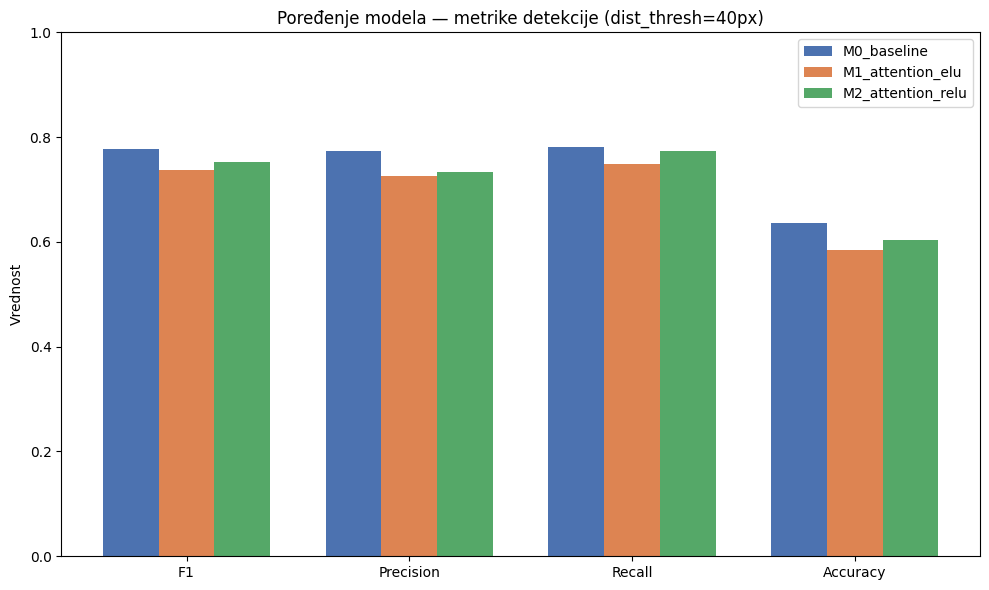

In [9]:
metrics_to_plot = ["F1", "Precision", "Recall", "Accuracy"]
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = {"M0_baseline": "#4C72B0", "M1_attention_elu": "#DD8452", "M2_attention_relu": "#55A868"}

for i, name in enumerate(MODEL_SPECS):
    vals = [results[name][m] for m in metrics_to_plot]
    ax.bar(x + (i - 1) * width, vals, width, label=name, color=colors[name])

ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Vrednost")
ax.set_title(f"Poređenje modela — metrike detekcije (dist_thresh={DIST_THRESH}px)")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

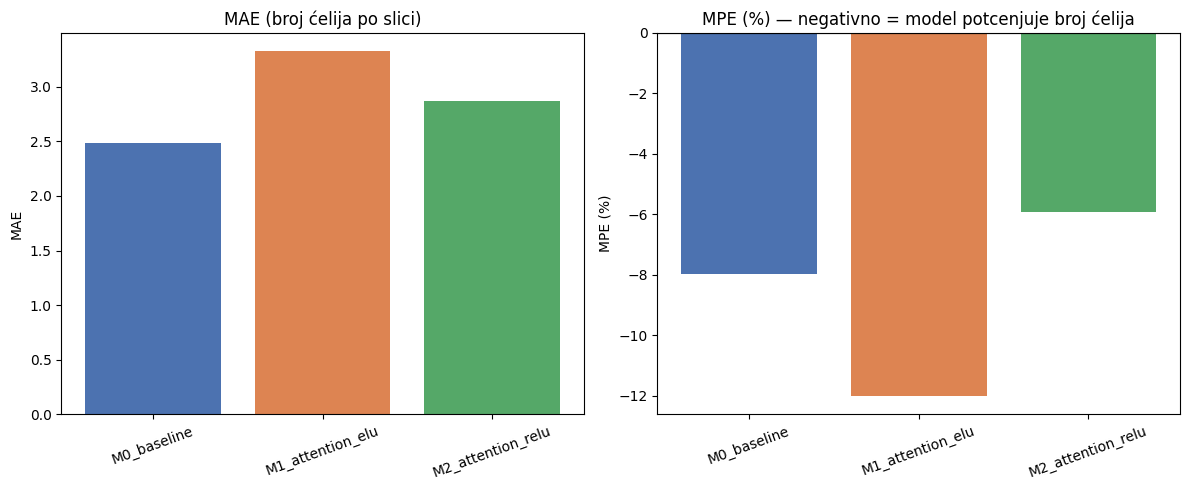

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
names = list(MODEL_SPECS.keys())

ax[0].bar(names, [results[n]["MAE"] for n in names], color=[colors[n] for n in names])
ax[0].set_title("MAE (broj ćelija po slici)")
ax[0].set_ylabel("MAE")
ax[0].tick_params(axis='x', rotation=20)

ax[1].bar(names, [results[n]["MPE"] for n in names], color=[colors[n] for n in names])
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].set_title("MPE (%) — negativno = model potcenjuje broj ćelija")
ax[1].set_ylabel("MPE (%)")
ax[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

## 6. Osetljivost na prag rastojanja (deskriptivno, NE utiče na izabranu vrednost)

Prag `dist_thresh=40` je fiksiran UNAPRED (obrazloženje u `src/evaluation.py`),
NE biran pretragom po najboljem F1 na testu — to bi bio data leakage (biranje
na testu). Grafik ispod je isključivo ilustrativan, da pokažemo da izbor 40 nije
na "ivici" nestabilnog regiona krive.

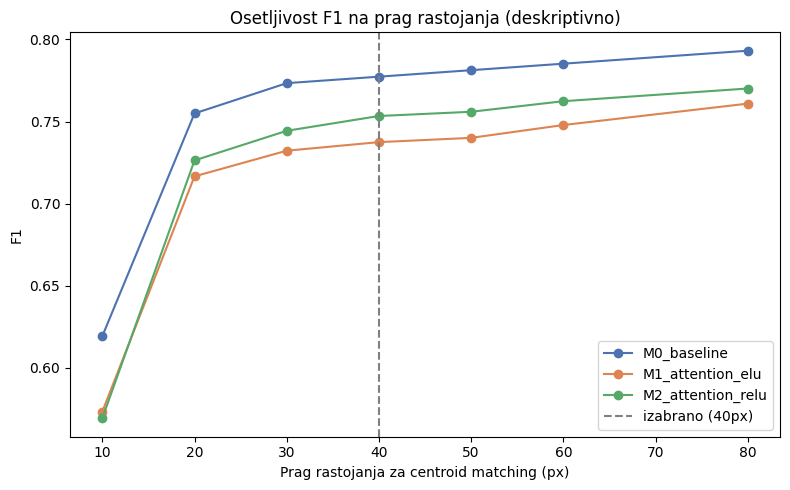

In [11]:
dist_range = [10, 20, 30, 40, 50, 60, 80]
f1_by_dist = {name: [] for name in MODEL_SPECS}
for d in dist_range:
    for name in MODEL_SPECS:
        r = evaluate(pred_labeled[name], gt_labeled, dist_thresh=d)
        f1_by_dist[name].append(r["F1"])

fig, ax = plt.subplots(figsize=(8, 5))
for name in MODEL_SPECS:
    ax.plot(dist_range, f1_by_dist[name], marker="o", label=name, color=colors[name])
ax.axvline(DIST_THRESH, color="gray", linestyle="--", label=f"izabrano ({DIST_THRESH}px)")
ax.set_xlabel("Prag rastojanja za centroid matching (px)")
ax.set_ylabel("F1")
ax.set_title("Osetljivost F1 na prag rastojanja (deskriptivno)")
ax.legend()
plt.tight_layout(); plt.show()

## 7. Kvalitativna analiza

Biramo dva karakteristična test primera:
1. **Zbijena/gusta slika** — najviše GT ćelija u test skupu.
2. **Svetla/šumovita pozadina** — najviša prosečna svetlina slike u test skupu.

In [12]:
from PIL import Image as PILImage

# gusta slika
dense_iid = max(gt_counts, key=gt_counts.get)
print("Zbijena slika:", dense_iid, "-> GT ćelija:", gt_counts[dense_iid])

# svetla/šumovita slika (prosečna svetlina cele slike)
brightness = {}
for iid in test_ids:
    img = np.array(PILImage.open(config.IMG_DIR / iid).convert("RGB"))
    brightness[iid] = img.mean()
bright_iid = max(brightness, key=brightness.get)
print("Svetla/šumovita slika:", bright_iid, "-> prosečna svetlina:", f"{brightness[bright_iid]:.1f}",
      "| GT ćelija:", gt_counts[bright_iid])

Zbijena slika: Mar36bS1C6R2_DMr_200x_y.png -> GT ćelija: 67


Svetla/šumovita slika: Mar42S2C4R2_VLPAGr_200x_o.png -> prosečna svetlina: 32.2 | GT ćelija: 34


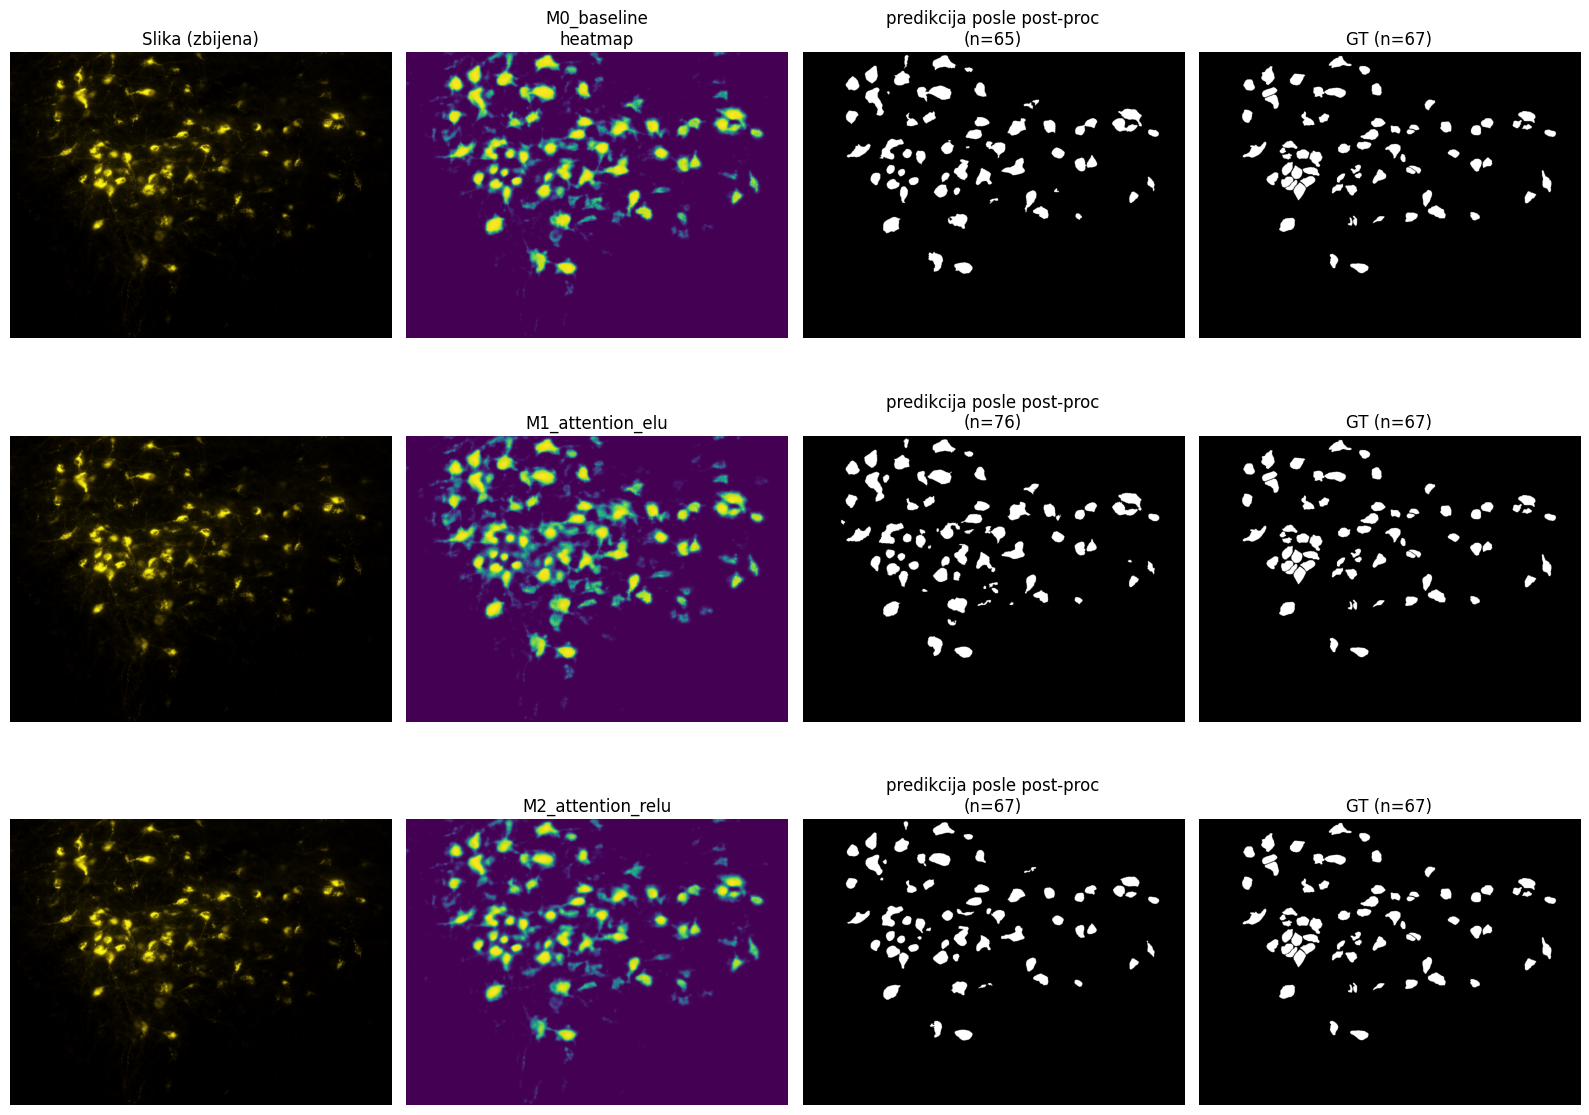

In [13]:
def show_qualitative(iid, title):
    img = np.array(PILImage.open(config.IMG_DIR / iid).convert("RGB"))
    fig, ax = plt.subplots(len(MODEL_SPECS), 4, figsize=(16, 4 * len(MODEL_SPECS)))
    for row, name in enumerate(MODEL_SPECS):
        heatmap = np.load(config.PREDS_DIR / name / f"{iid}.npy")
        pred_lab = pred_labeled[name][iid]
        ax[row, 0].imshow(img); ax[row, 0].set_title(f"Slika ({title})" if row == 0 else "")
        ax[row, 1].imshow(heatmap, cmap="viridis", vmin=0, vmax=1)
        ax[row, 1].set_title(f"{name}\nheatmap" if row == 0 else name)
        ax[row, 2].imshow(pred_lab > 0, cmap="gray")
        ax[row, 2].set_title(f"predikcija posle post-proc\n(n={pred_counts[name][iid]})")
        ax[row, 3].imshow(gt_labeled[iid] > 0, cmap="gray")
        ax[row, 3].set_title(f"GT (n={gt_counts[iid]})")
    for a in ax.ravel(): a.axis("off")
    plt.tight_layout(); plt.show()

show_qualitative(dense_iid, "zbijena")

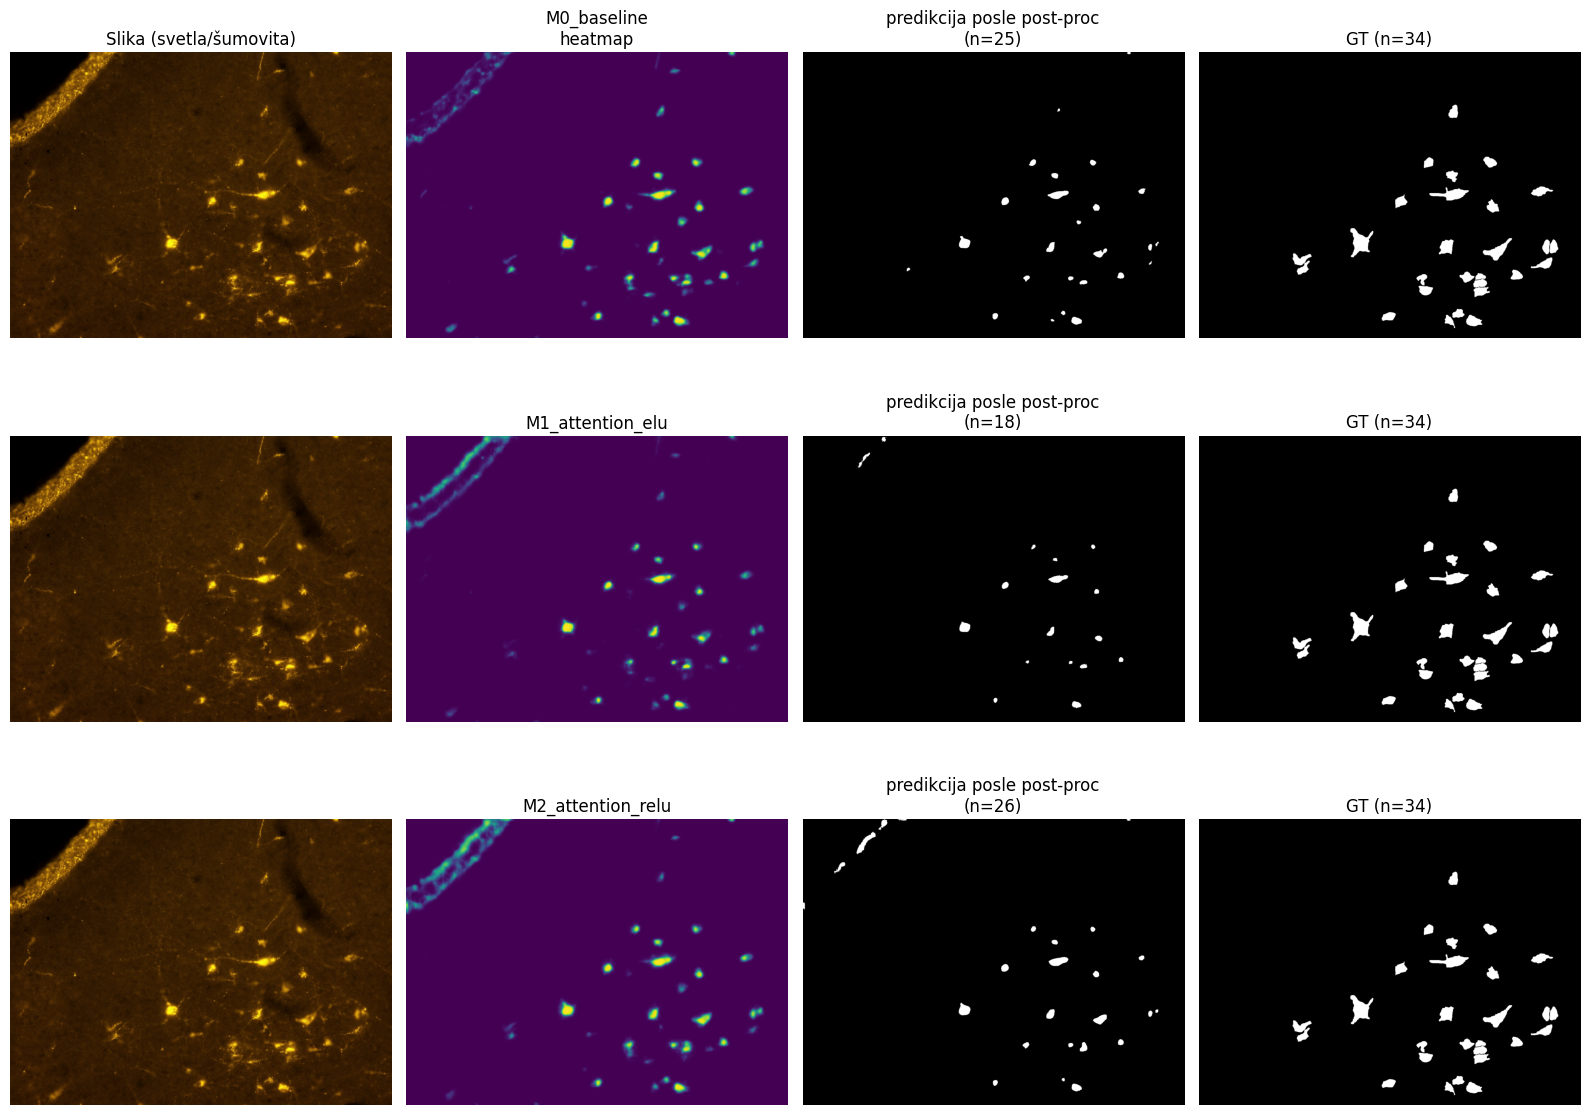

In [14]:
show_qualitative(bright_iid, "svetla/šumovita")

## 8. Zaključci

**Rezultati (test skup, 70 slika, dist_thresh=40px):**

| Model | F1 | Precision | Recall | MAE | MPE (%) |
|---|---|---|---|---|---|
| M0 baseline | 0.777 | 0.774 | 0.780 | 2.49 | -7.98 |
| M1 attention+ELU | 0.737 | 0.727 | 0.749 | 3.33 | -12.01 |
| M2 attention+ReLU | 0.753 | 0.734 | 0.774 | 2.87 | -5.94 |

**1. Sanity check — baseline se poklapa sa najjačom referencom u literaturi.**
Naš M0 (F1=0.777, MAE=2.49) gotovo tačno pogađa baseline iz literature — originalni
model treniran na PUNOM skupu SA weight mapama (F1=0.7835, MAE=2.74) — iako mi
NEMAMO weight mape. Ovo je jak signal da su split/threshold/eval protokol ispravno
implementirani.

**2. Attention modeli KOD NAS zaostaju za baseline-om, ali MNOGO MANJE nego u
referentnim publikacijama.** Referentne vrednosti pokazuju veći pad sa attention-om
kada se koristi smanjen uzorak. Naš pad je od jačeg baseline-a: F1 0.777→0.737
(ELU) / →0.753 (ReLU) — apsolutno mnogo bolji rezultati za attention modele
(F1 preko 0.73 vs ~0.5-0.57 u referenci). **Ključni razlog:** naša tri modela
(M0, M1, M2) su sva trenirana na ISTOM punom, augmentovanom train skupu — mi
testiramo ČIST efekat attention mehanizma na dovoljnoj količini podataka, bez
konfaunda sa veličinom uzorka.

**3. ReLU (M2) je kod nas blago NADMAŠIO ELU (M1).**
Ovo je dokumentovana razlika u konkretnom trening run-u (M1 stao na 35. epohi,
M2 na 46., notebook 04) — različit broj efektivnih koraka treninga, drugačiji
val split. Razlika je mala (0.016 F1); ne izvodimo opšti zaključak, samo
beležimo nalaz za ovaj konkretan run.

**4. Svi modeli SISTEMATSKI PREBROJÁVAJU broj ćelija** (MPE negativan za sva tri:
-7.98%, -12.01%, -5.94%). MPE negativan znači n_pred > n_true — modeli dodaju
više objekata nego što stvarno postoji. M1 (attention+ELU) najviše prebrojava
(-12.01%, ujedno i najveći MAE) — najagresivniji od tri modela. Ova tendencija
je očekivana posledica weighted BCE (koja penalizira false negatives strože) i
post-processing pipeline-a (watershed razdvaja dodirnute ćelije, što može dovesti
do povećanja broja detektovanih objekata).

**5. Kvalitativno (odeljak 7):** heatmape na zbijenoj slici (67 GT ćelija) i na
svetloj/šumovitoj slici (34 GT ćelija, najveća prosečna svetlina u test skupu)
pokazane su iznad za sva tri modela — vizuelna inspekcija pokazuje gde se
predikcija razlikuje od GT-a po modelu.

**Ukupan zaključak:** rangiranje modela je M0 > M2 > M1 po F1. Baseline ostaje
najjači model, ali razlika između baseline-a i attention modela je mnogo manja
nego u referentnim publikacijama — objašnjeno razlikom u protokolu treninga
(pun augmentovan skup za sva tri modela).